* Contrast Stickiness vs. Listening Time
* Acquisition Rate vs. Retention

Findings
* Diff archetypes


Divide into... 
- Long term retention trends?
- Behavior (frequent but short sessions, infrequent but long sessions)
     >>> It makes sense that mobile might be shorter sessions, while usage where you're stuck in one place is going to be longer?


Carousel: for highlighting difference between MU and CU

- > Web... likely initial sign on platform, but not effective listening platform. Likely transferring to other platforms

-> Highlighht key difference between Android and diOS

In [1]:
import pandas as pd
import polars as pl
from plotnine import *

from polars import col, lit, when

import plotly.express as px

In [2]:
def format_df_date_column(
        df: pl.DataFrame,
        date_col: str = "day",
) -> pl.DataFrame:
        
        df = (
                df.with_columns(
                        col(date_col).str.split("/").list.to_struct(fields=["Month", "Day", "Year"]).alias("unpacked")
                )
                .unnest("unpacked")
                .with_columns(
                        (lit("20") + col("Year")).alias("Year"),
                )
                .with_columns(
                        col("Month", "Day", "Year").cast(pl.Int64),
                        col(date_col).str.to_date("%m/%d/%y").alias("Date")
                )
                .with_columns(
                        pl.col("Date").dt.weekday().alias("DayOfWeek"),
                        pl.col("Date").dt.strftime("%A").alias("DayOfWeekStr"),
                )
                .with_columns(
                        when(col("DayOfWeek").is_in([6, 7]))
                        .then(lit("Weekend"))
                        .otherwise(lit("Weekday"))
                        .alias("WeekdayOrWeekend")
                )
                .rename({"day": "DayStr",})
        )
        return df


DF Setup

Year,Month,Platform,Listeners
i64,i64,str,f64
2018,1,"""Web""",8.1500e6
2018,1,"""Amazon""",2.4729e6
2018,1,"""Android""",1.8729e7
2018,1,"""All_Other""",5.0546e6
2018,1,"""iOS""",2.7803e7
…,…,…,…
2020,12,"""Amazon""",1.6552881e7
2020,12,"""Android""",7.0014e7
2020,12,"""iOS""",7.8624e7


In [ ]:
df_mu = pl.read_csv("Data/Monthly_Listeners.txt", separator="\t")
df_du = pl.read_csv("Data/Daily_Listeners.txt", separator="\t")
df_ds = pl.read_csv("Data/Daily_Seconds_Listened.txt", separator="\t")
df_cu = pl.read_csv("Data/All-Time_Listeners.txt", separator="\t")

df_mu = (
    df_mu.with_columns(
        (
            pl.col("Year").cast(pl.Utf8) 
            + "-" 
            + pl.col("Month").cast(pl.Utf8).str.zfill(2)
        )
        .alias("YearMonth")
    )
    .with_columns(
        col("YearMonth").str.to_date("%Y-%m").alias("Date")
    )
    .rename({"Listeners": "NumListeners"})
)

df_du = (
    format_df_date_column(df_du)
    .rename({
        "platform": "Platform",
        "listeners": "NumListeners", 
    })
)

df_ds = (
    format_df_date_column(df_ds)
    .rename({
        "platform": "Platform",
        "seconds": "NumSecondsListened", 
    })
)


df_du_monthly_agg = (
    df_du.group_by("Platform", "Month", "Year")
    .agg(
        col("NumListeners").sum().alias("TotalDailyUniques"),
        col("NumListeners").mean().alias("MeanDailyUniques"),
    )
)

df_mu_du = (
    df_mu.join(
        df_du_monthly_agg,
        on=["Platform", "Month", "Year"],
        how="left"
    )
    .rename({"NumListeners": "MonthlyUniques"})
    .with_columns(
        (col("TotalDailyUniques")/col("MonthlyUniques")).alias("AvgDaysListened"),
        # Stickiness = On any given day, what percentage of this month's active users are using this product?
        #   e.g., 10% for January = On an average day in January, 10% of everyone who used the service at least once
        #     that month is active
        #   30 days X 10% = an average of 3 days per month
        (col("MeanDailyUniques")/col("MonthlyUniques")).alias("Stickiness"),
    )
)

df_du_ds = (
    df_du.join(
        df_ds, 
        on=["DayStr", "Platform", "Month", "Day", "Year", "Date", "DayOfWeek", "DayOfWeekStr", "WeekdayOrWeekend"], 
        how="left"
    )
    .with_columns((col("NumSecondsListened") / col("NumListeners")).alias("SecondsPerListener"))
)


df_ds_monthly_sum = (
    df_ds.group_by("Platform", "Month", "Year")
    .agg(col("NumSecondsListened").sum().alias("TotalSecondsListened"))
)
df_mu_du_ds = (
    df_mu_du.join(
        df_ds_monthly_sum, 
        on=["Platform", "Month", "Year"], 
        how="left"
    )
    .with_columns(
        (col("TotalSecondsListened") / col("TotalDailyUniques")).alias("AvgSecondsPerDAU"),
        (col("TotalSecondsListened") / col("MonthlyUniques")).alias("AvgSecondsPerMAU"),
    )

    # Create normalized version (share of total for each month) for Stickiness and Seconds listened metrics 
    # This will allow comparitive plotting between the different metrics
    .with_columns(
        (col("AvgDaysListened") / col("AvgDaysListened").sum().over(["Year", "Month"]))
            .alias("AvgDaysListened_Normalized"),
        (col("AvgSecondsPerMAU") / col("AvgSecondsPerMAU").sum().over(["Year", "Month"]))
            .alias("AvgSecondsPerMAU_Normalized")

    )
)


# Confirm that all normalized values sum to 1 for each month
#  (rounds to 7 to allow floating point tolerance)
assert all(x == 1 for x in df_mu_du_ds.group_by("Year", "Month").agg(col("AvgDaysListened_Normalized").sum().round(7))["AvgDaysListened_Normalized"].to_list())
assert all(x == 1 for x in df_mu_du_ds.group_by("Year", "Month").agg(col("AvgSecondsPerMAU_Normalized").sum().round(7))["AvgSecondsPerMAU_Normalized"].to_list())
df_mu_du_ds

df_cu = df_cu.rename({"Listeners": "CumulativeUniques"})

df_mu_cu = df_mu.join(
    df_cu,
    how="left",
    on=["Year", "Month", "Platform"]
)



Year,Month,Platform,NumListeners,YearMonth,Date,CumulativeUniques
i64,i64,str,f64,str,date,f64
2018,1,"""All_Other""",5.0546e6,"""2018-01""",2018-01-01,5.0546e6
2018,1,"""Amazon""",2.4729e6,"""2018-01""",2018-01-01,2.4729e6
2018,1,"""Android""",1.8729e7,"""2018-01""",2018-01-01,1.8729e7
2018,1,"""Roku""",2.07789e6,"""2018-01""",2018-01-01,2.07789e6
2018,1,"""Web""",8.1500e6,"""2018-01""",2018-01-01,8.1500e6
…,…,…,…,…,…,…
2020,12,"""Amazon""",1538050.5,"""2020-12""",2020-12-01,1.6552881e7
2020,12,"""Android""",1.7230e7,"""2020-12""",2020-12-01,7.0014e7
2020,12,"""Roku""",3399923.7,"""2020-12""",2020-12-01,9233961.3


In [ ]:
start_date = df_mu_cu["Date"].min()
end_date = df_mu_cu["Date"].max()

TypeError: strftime() missing required argument 'format' (pos 1)

In [49]:
pct_change_mus_cus = (
    df_mu_cu.filter(
        (col("Date") == col("Date").min().over("Platform")) |
        (col("Date") == col("Date").max().over("Platform"))
    )
    .select("YearMonth", "Platform", "NumListeners", "CumulativeUniques")
    .pivot(
        index="Platform",
        on="YearMonth"
    )
    .with_columns(
        ((col("NumListeners_2020-12") - col("NumListeners_2018-01"))/col("NumListeners_2018-01")).alias("PctChangeMAU"),
        ((col("CumulativeUniques_2020-12") - col("CumulativeUniques_2018-01"))/col("CumulativeUniques_2018-01")).alias("PctCumUniques"),
    )
)

pct_change_mus_cus


Platform,NumListeners_2018-01,NumListeners_2020-12,CumulativeUniques_2018-01,CumulativeUniques_2020-12,PctChangeMAU,PctCumUniques
str,f64,f64,f64,f64,f64,f64
"""Web""",8.1500e6,6134662.8,8.1500e6,6.8104e7,-0.247279,7.356316
"""All_Other""",5.0546e6,8201977.2,5.0546e6,3.8790e7,0.622691,6.6743
"""iOS""",2.7803e7,2.9912e7,2.7803e7,7.8624e7,0.075863,1.827893
"""Android""",1.8729e7,1.7230e7,1.8729e7,7.0014e7,-0.080082,2.738164
"""Amazon""",2.4729e6,1538050.5,2.4729e6,1.6552881e7,-0.37804,5.693687
"""Roku""",2.07789e6,3399923.7,2.07789e6,9233961.3,0.636239,3.443912


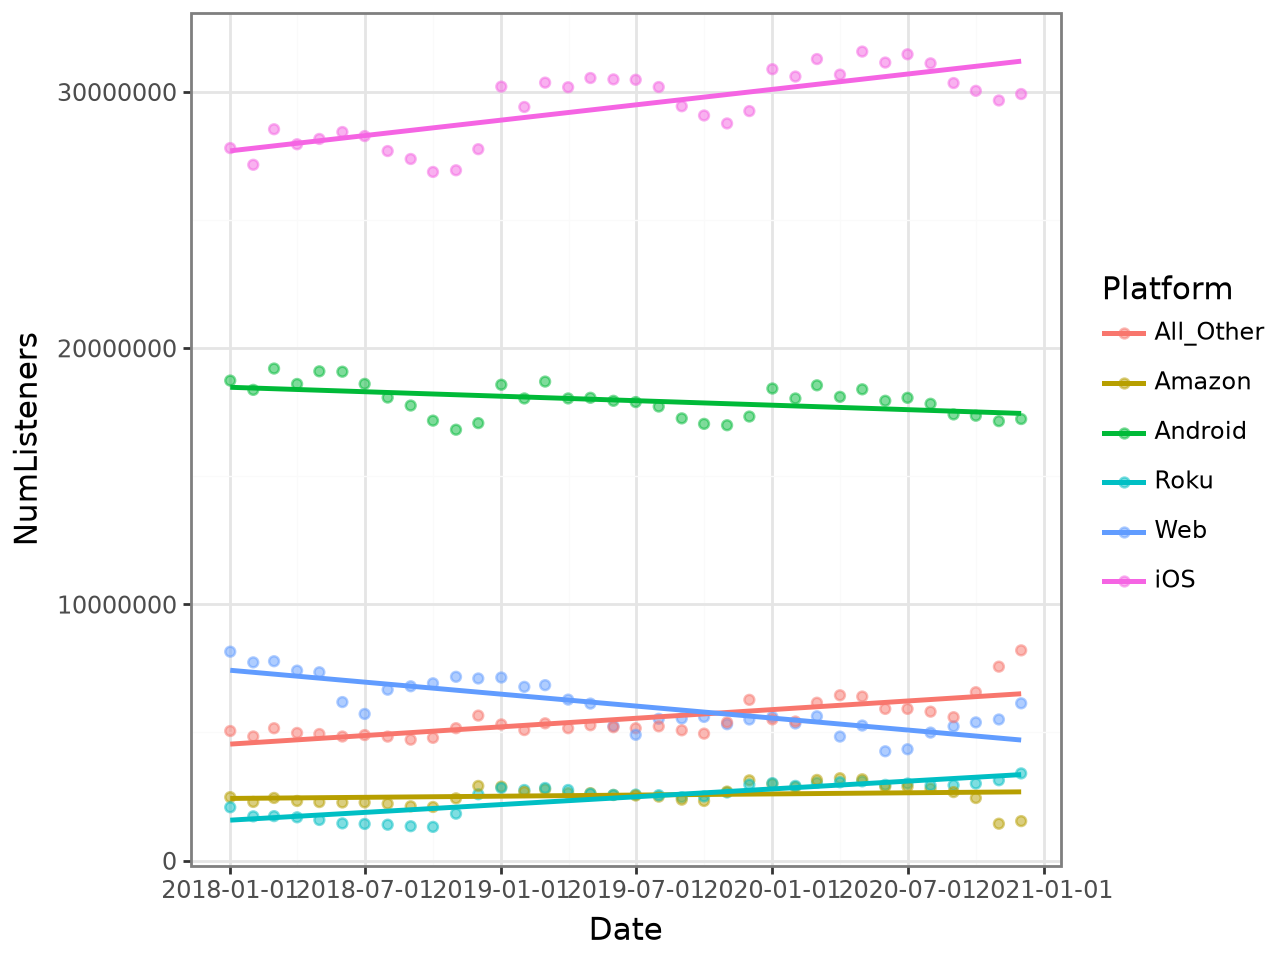

In [37]:
(
    ggplot(data=df_mu_cu, mapping=aes(x="Date", y="NumListeners", color="Platform"))
    + geom_point(alpha=.5)
    + geom_smooth(method="lm", se=False)
    + theme_bw()
    + theme_bw()
)

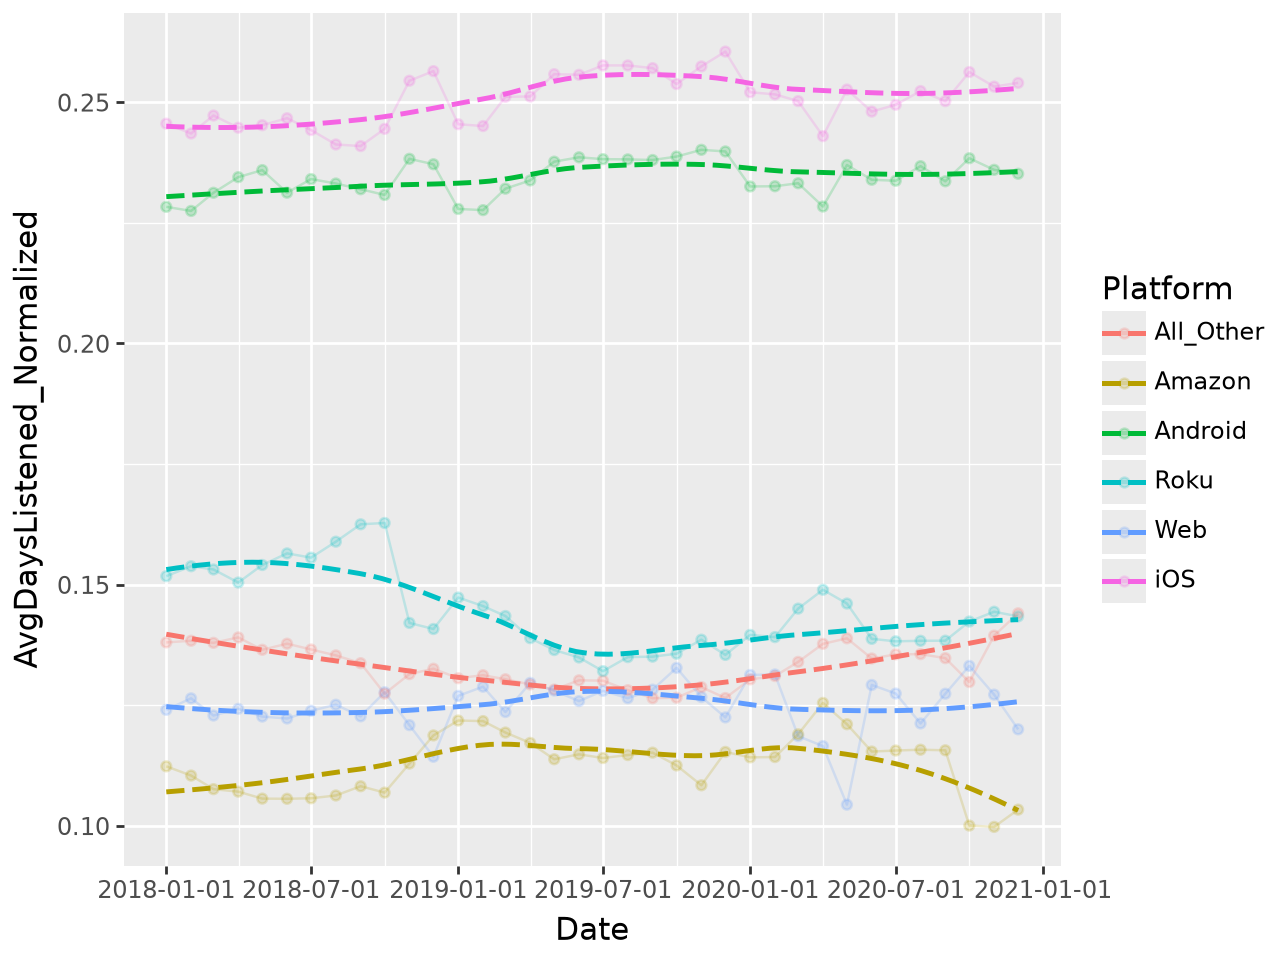

In [4]:
(
    ggplot(
        data=df_mu_du_ds,
        mapping=aes(x="Date", y="AvgDaysListened_Normalized", color="Platform")
    )
    + geom_line(alpha=.2)
    + geom_point(alpha=.2)
    + geom_smooth(linetype="dashed", se=False)

)

In [19]:
df_mu

Year,Month,Platform,NumListeners,YearMonth,Date
i64,i64,str,f64,str,date
2018,1,"""Web""",8.1500e6,"""2018-01""",2018-01-01
2018,1,"""All_Other""",5.0546e6,"""2018-01""",2018-01-01
2018,1,"""Roku""",2.07789e6,"""2018-01""",2018-01-01
2018,1,"""Android""",1.8729e7,"""2018-01""",2018-01-01
2018,1,"""iOS""",2.7803e7,"""2018-01""",2018-01-01
…,…,…,…,…,…
2020,12,"""Android""",1.7230e7,"""2020-12""",2020-12-01
2020,12,"""Roku""",3399923.7,"""2020-12""",2020-12-01
2020,12,"""All_Other""",8201977.2,"""2020-12""",2020-12-01


In [6]:
df_mu_du_ds

Year,Month,Platform,MonthlyUniques,YearMonth,Date,TotalDailyUniques,MeanDailyUniques,AvgDaysListened,Stickiness,TotalSecondsListened,AvgSecondsPerDAU,AvgSecondsPerMAU,AvgDaysListened_Normalized,AvgSecondsPerMAU_Normalized
i64,i64,str,f64,str,date,f64,f64,f64,f64,i64,f64,f64,f64,f64
2018,9,"""Amazon""",2.1164e6,"""2018-09""",2018-09-01,9.652755e6,321758.5,4.560936,0.152031,64638123012,6696.339336,30541.57459,0.108199,0.090108
2018,7,"""All_Other""",4.8963e6,"""2018-07""",2018-07-01,2.8479e7,918672.788013,5.816437,0.187627,414796655677,14565.074153,84716.830185,0.136552,0.241957
2018,1,"""Web""",8.1500e6,"""2018-01""",2018-01-01,4.3345e7,1.3982e6,5.318378,0.171561,429201717622,9902.066122,52662.925906,0.12403,0.156163
2018,11,"""iOS""",2.6937e7,"""2018-11""",2018-11-01,2.8009e8,9.3364e6,10.398173,0.346606,1481597894737,5289.661997,55002.8191,0.254464,0.162083
2018,1,"""All_Other""",5.0546e6,"""2018-01""",2018-01-01,2.9913e7,964930.391719,5.917999,0.190903,422494368525,14124.18006,83586.881134,0.138014,0.247862
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2020,8,"""Android""",1.7825e7,"""2020-08""",2020-08-01,1.8247e8,5.8860e6,10.236796,0.330219,1193606972444,6541.500093,66963.999024,0.236755,0.188834
2020,2,"""iOS""",3.0595e7,"""2020-02""",2020-02-01,3.2865e8,1.1333e7,10.741995,0.370414,1642473403281,4997.639551,53684.620431,0.251641,0.154699
2020,8,"""Roku""",2938621.5,"""2020-08""",2020-08-01,1.7579e7,567062.912903,5.98204,0.192969,146367917748,8326.317286,49808.360059,0.138352,0.140456


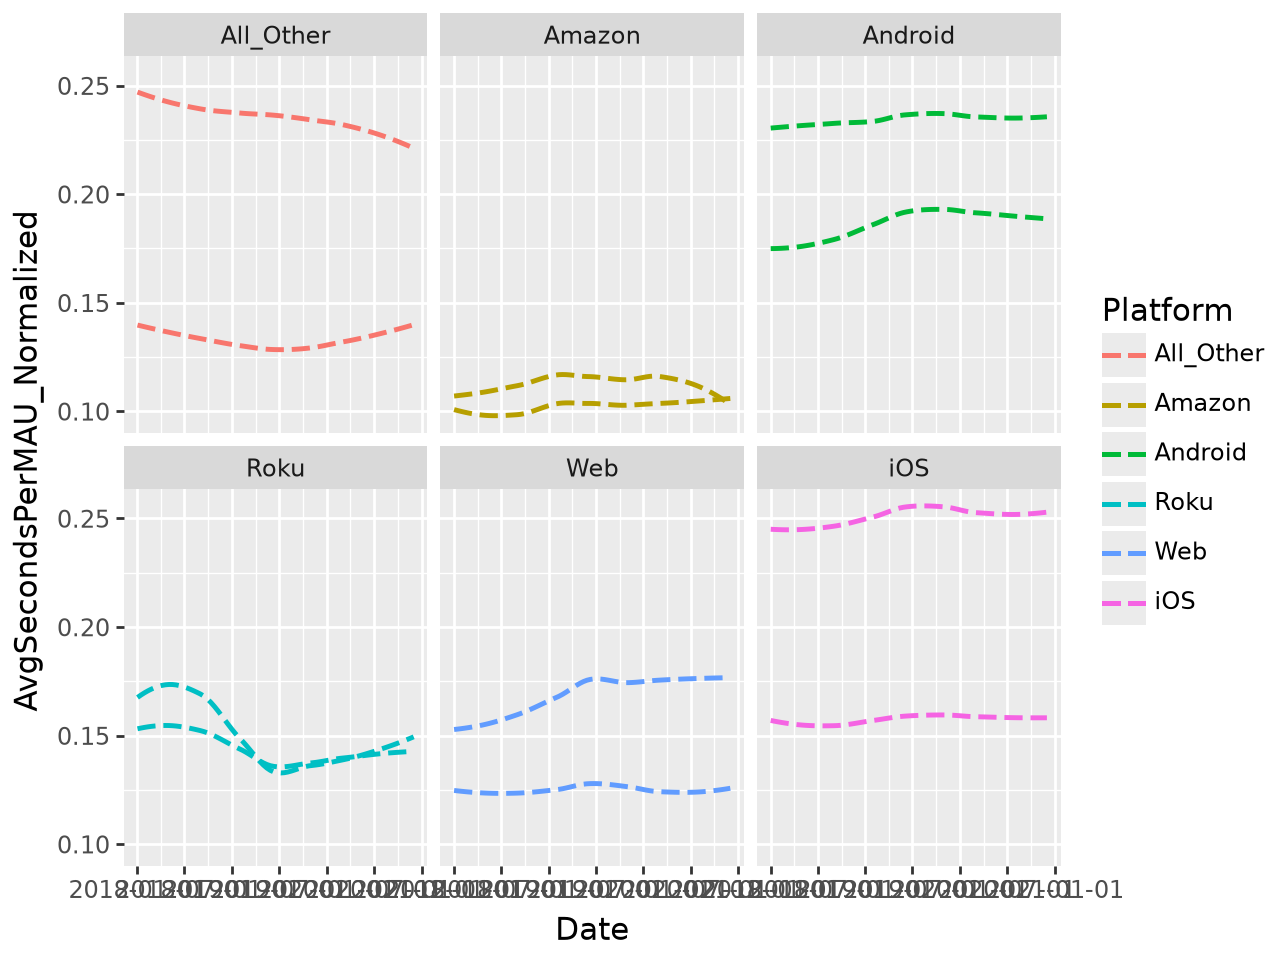

In [7]:
(
    ggplot(
        data=df_mu_du_ds,
        mapping=aes(x="Date", y="AvgSecondsPerMAU_Normalized", color="Platform")
    )
    + geom_line(alpha=.2)
    + geom_point(alpha=.2)
    + geom_smooth(linetype="dashed", se=False)

)

(
    ggplot(
        data=df_mu_du_ds,
        mapping=aes(x="Date", y="AvgSecondsPerMAU_Normalized", color="Platform")
    )
    + facet_wrap("Platform")
    + geom_smooth(linetype="dashed", se=False)
    + geom_smooth(mapping=aes(y="AvgDaysListened_Normalized"), linetype="dashed", se=False)

)

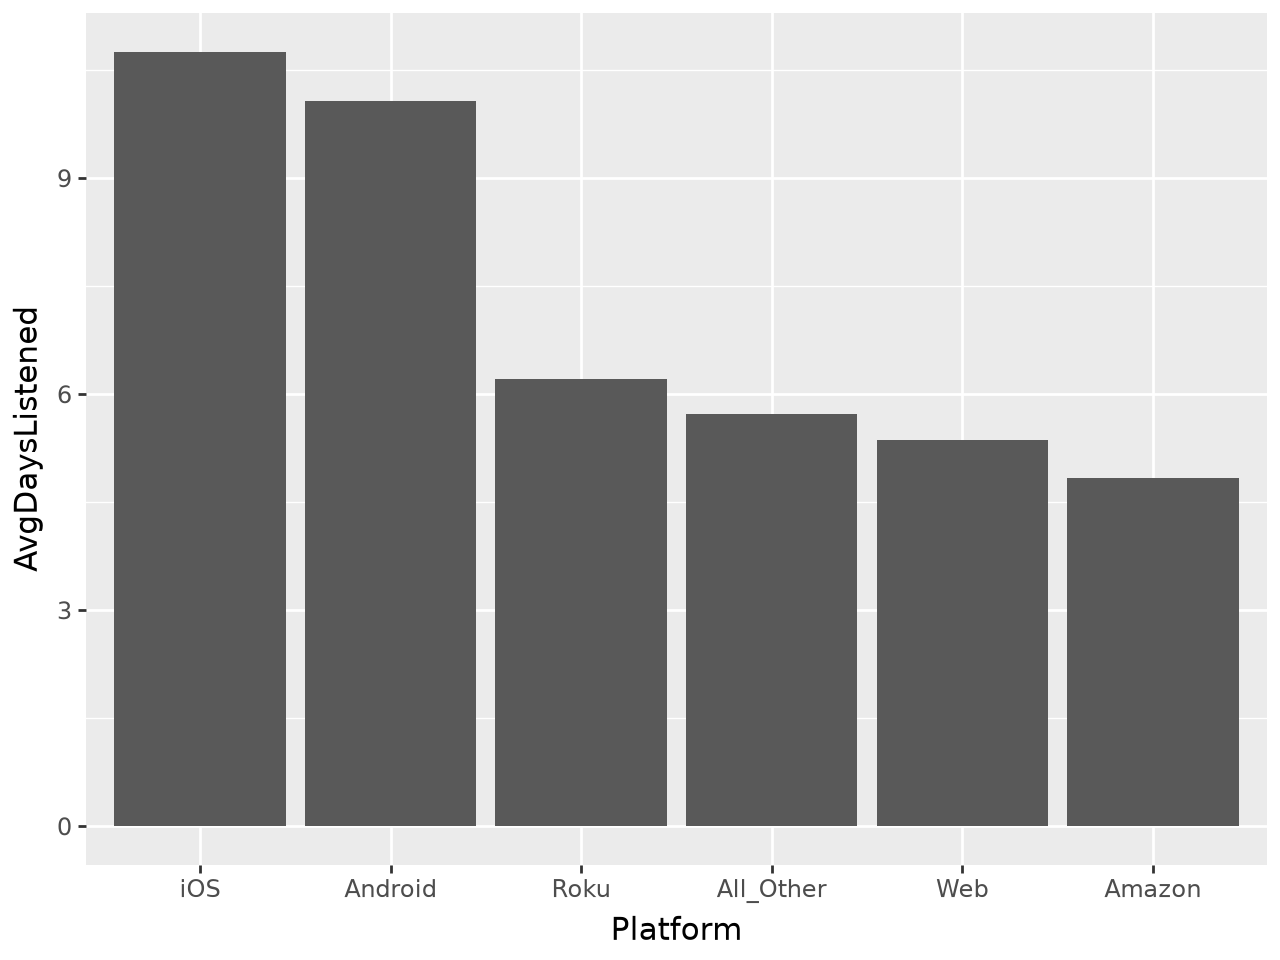

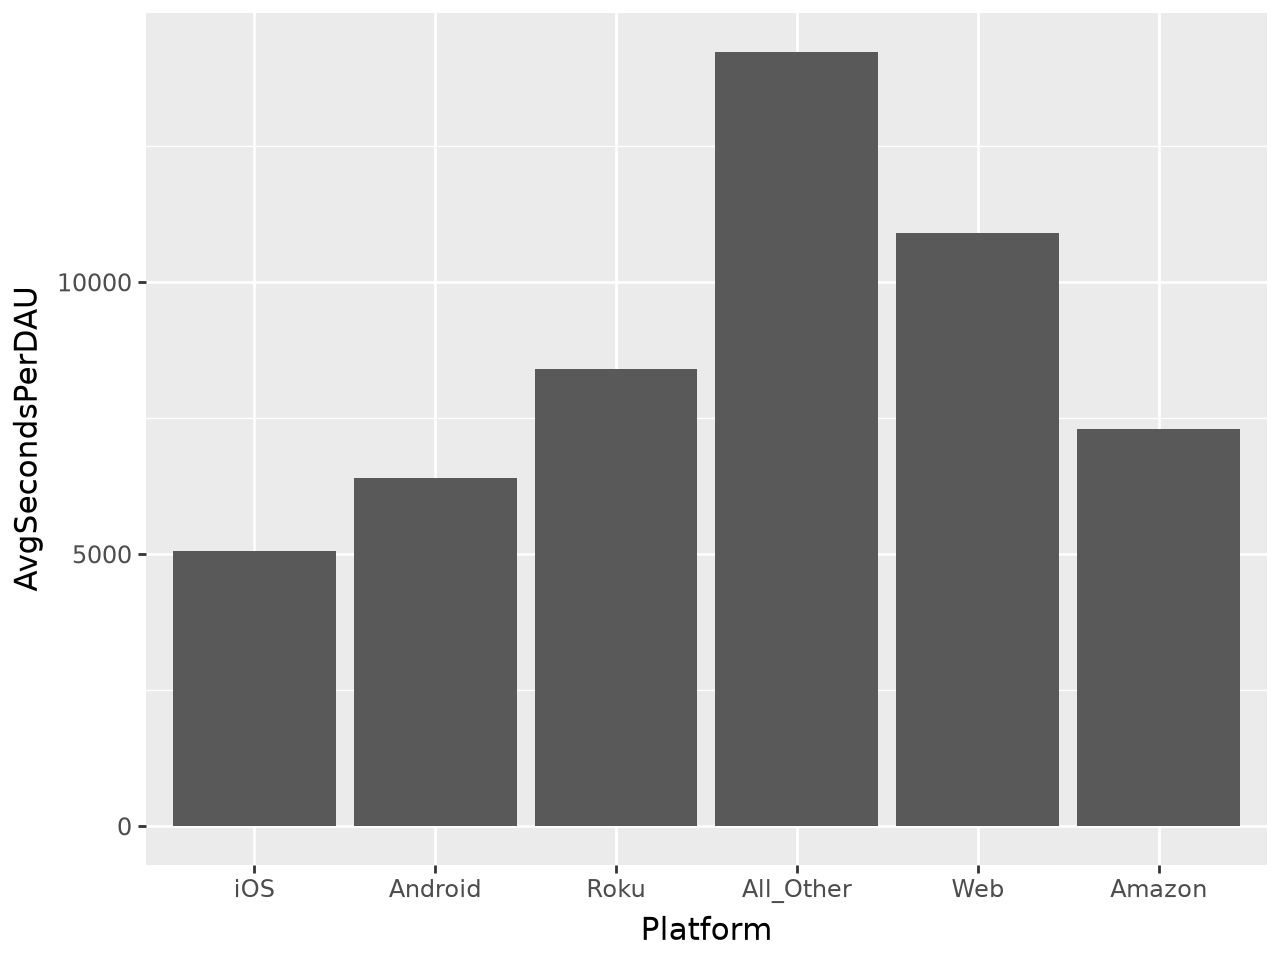

In [8]:

# Averaging across each month in the dataset...
overall_avg_days_listened = df_mu_du_ds.group_by("Platform").agg(col("AvgDaysListened").mean()).sort("AvgDaysListened", descending=True)
overall_avg_seconds_per_dau = df_mu_du_ds.group_by("Platform").agg(col("AvgSecondsPerDAU").mean()).sort("AvgSecondsPerDAU", descending=True)

overall_avgs = overall_avg_days_listened.join(
    overall_avg_seconds_per_dau,
    how="left",
    on="Platform"
)

order_overall_avg_days_listened = (
    overall_avgs#.select(["Platform", "PctChangeWeekendVsWeekday"])
    # .unique(subset=["Platform"])
    .sort("AvgDaysListened", descending=True)
    .get_column("Platform")
    .to_list()
)


overall_avgs = overall_avgs.with_columns(
    col("Platform").cast(pl.Enum(categories=order_overall_avg_days_listened))
)

display(
    ggplot(data=overall_avgs, mapping=aes(x="Platform", y="AvgDaysListened"))
    + geom_col(),

    ggplot(data=overall_avgs, mapping=aes(x="Platform", y="AvgSecondsPerDAU"))
    + geom_col(),

)


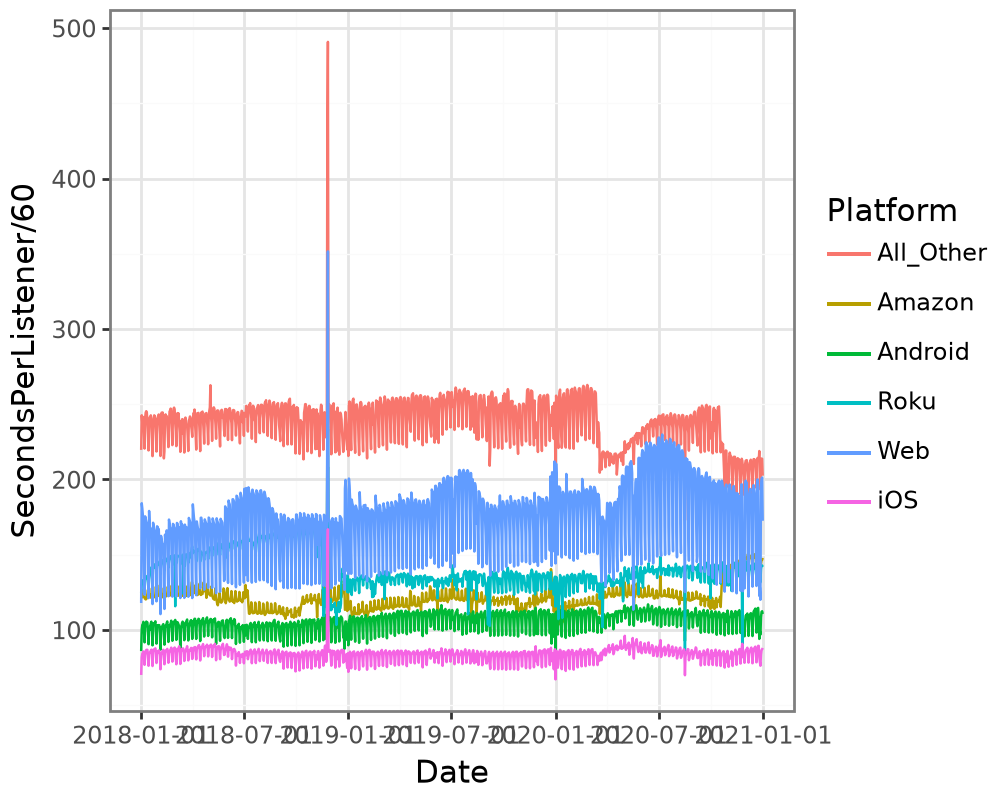

In [9]:
(
    ggplot(data=df_ds, mapping=aes(x="Date", y="NumSecondsListened", fill="Platform", color="Platform"))
    + geom_line()
)

(
    ggplot(data=df_du_ds, mapping=aes(x="Date", y="SecondsPerListener/60", fill="Platform", color="Platform"))
    + geom_line()
    # + geom_smooth(method="loess")
    # + scale_x_date(date_breaks="1 day", date_labels="%a")
    # + coord_cartesian(xlim=[pd.to_datetime("2018-01-01"), pd.to_datetime("2018-01-30")])
    + theme_bw()
    + theme(
       figure_size=[5, 4] 
    )
)

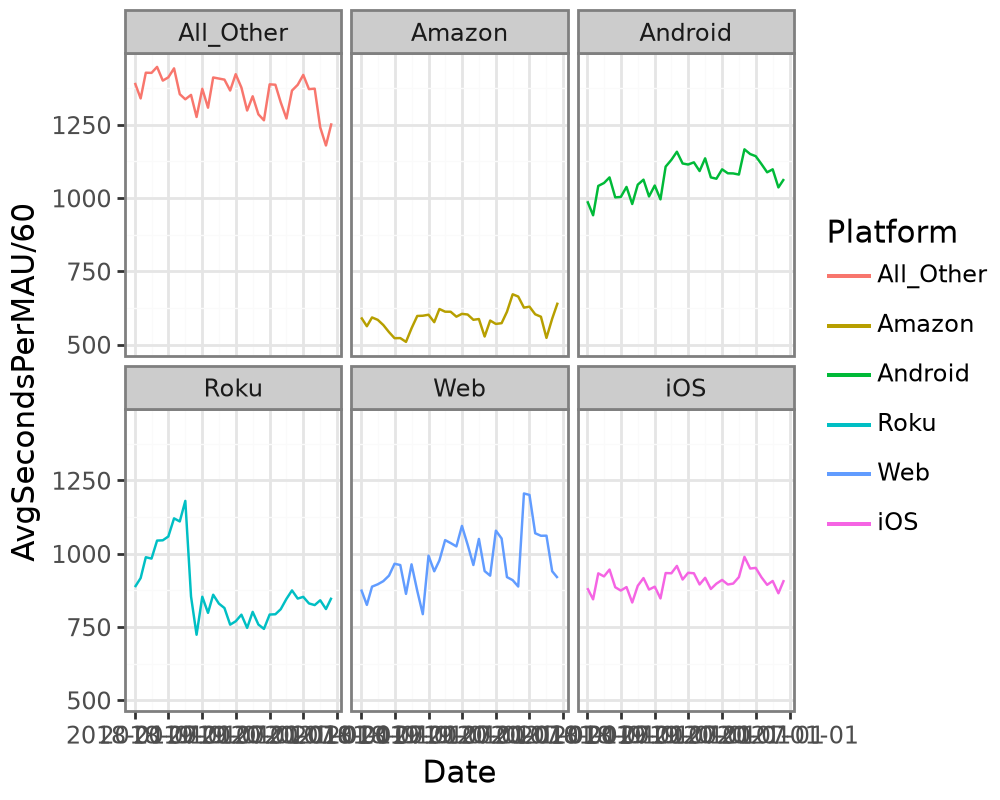

In [10]:
(
    ggplot(data=df_mu_du_ds, mapping=aes(x="Date", y="AvgSecondsPerMAU/60", fill="Platform", color="Platform"))
    + facet_wrap("Platform")
    + geom_line()
    # + geom_smooth(method="loess")
    # + scale_x_date(date_breaks="1 day", date_labels="%a")
    # + coord_cartesian(xlim=[pd.to_datetime("2018-01-01"), pd.to_datetime("2018-01-30")])
    + theme_bw()
    + theme(
       figure_size=[5, 4] 
    )
)

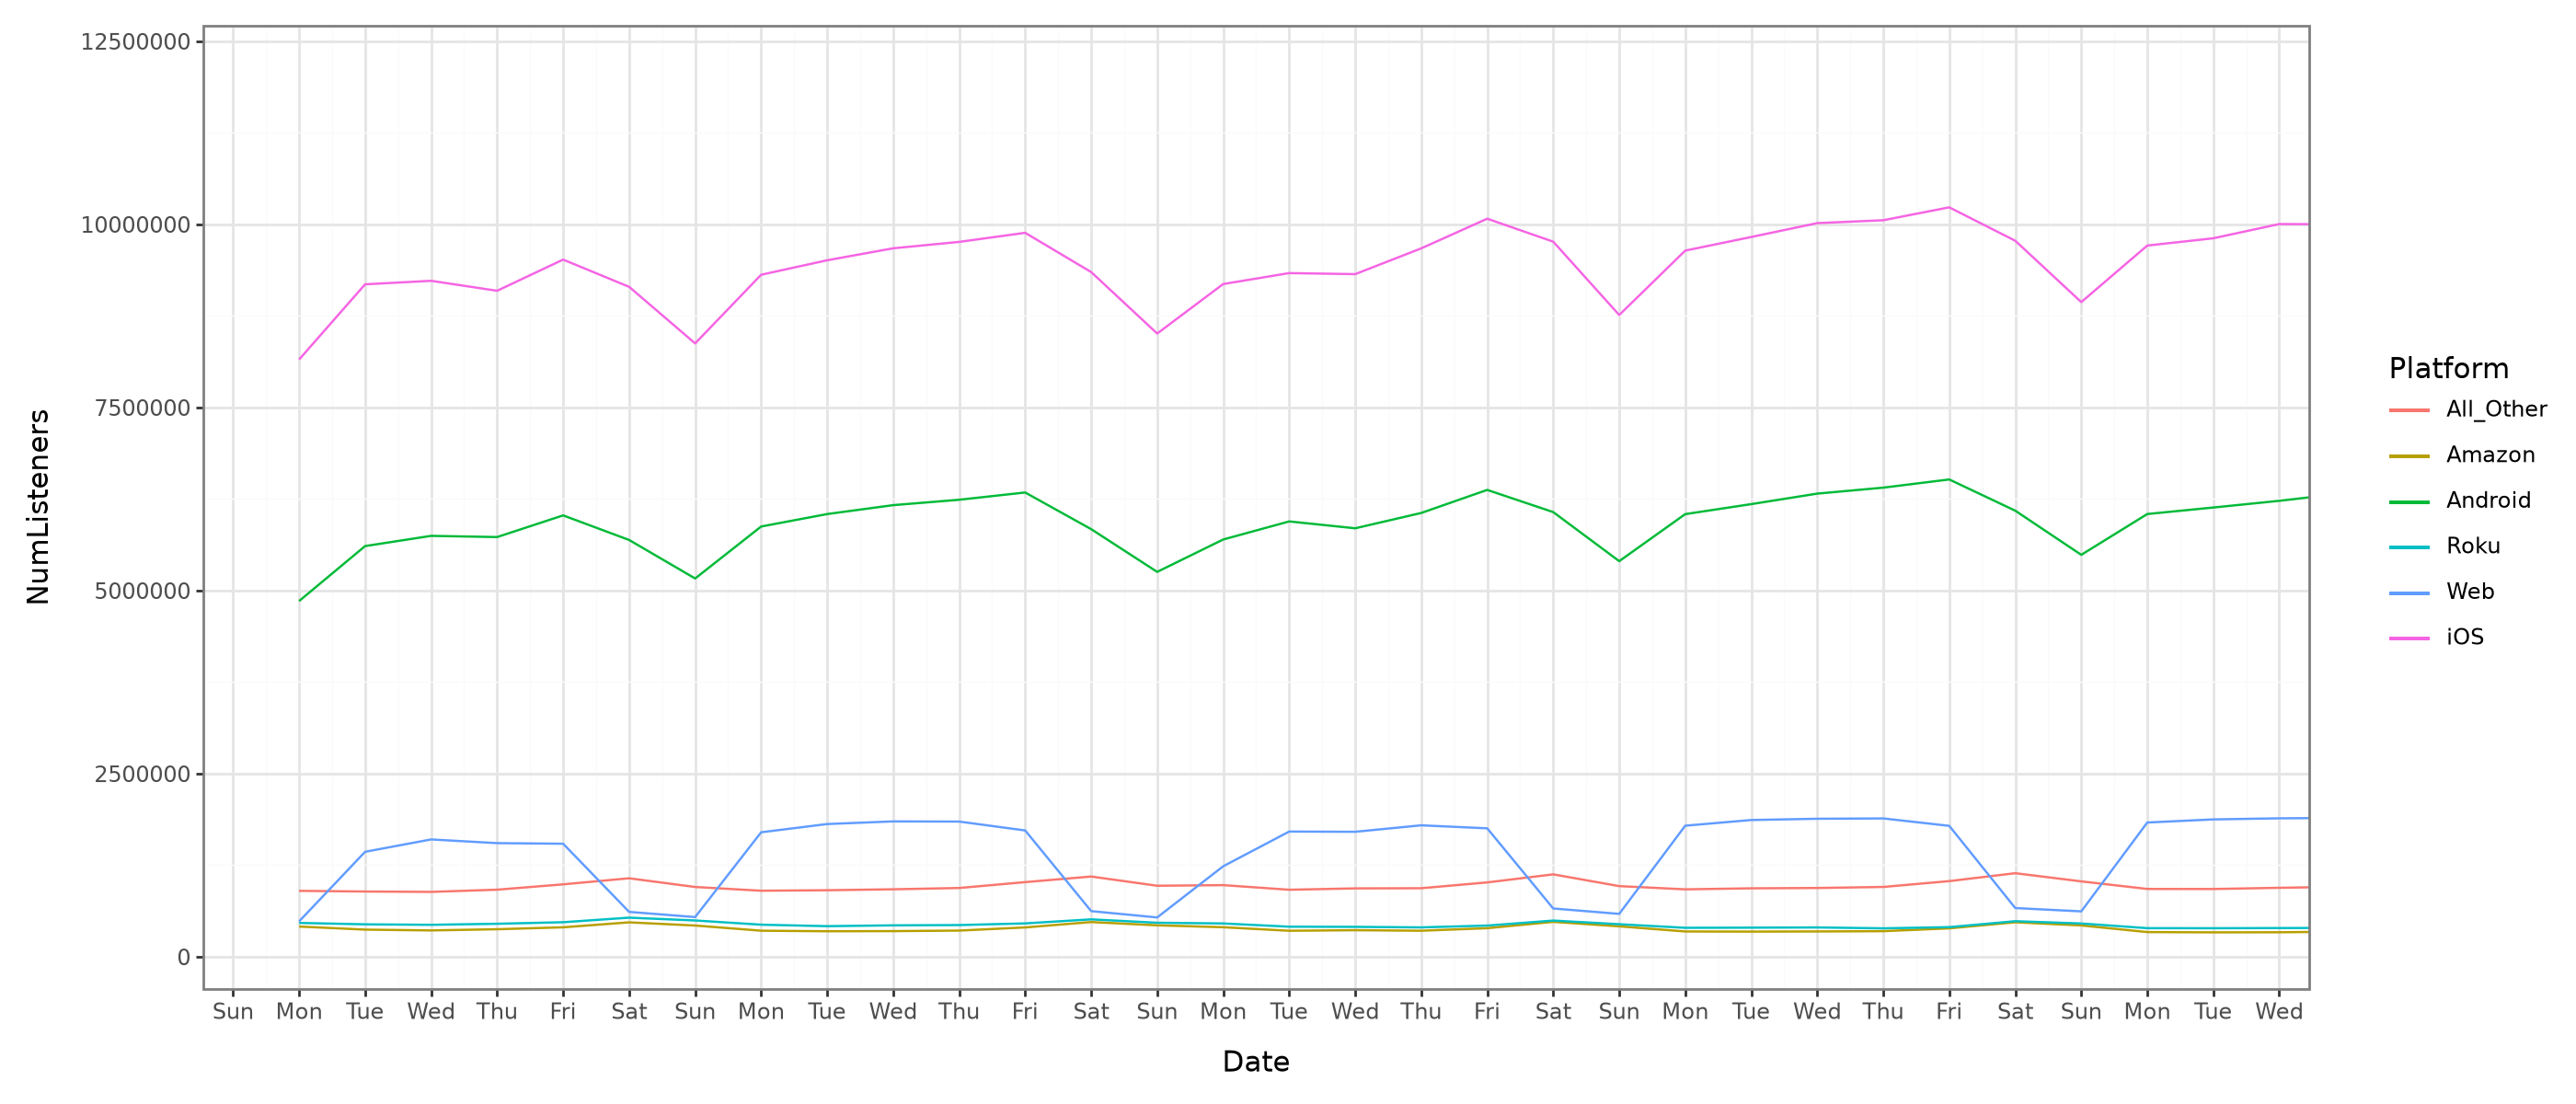

In [11]:
(
    ggplot(data=df_du, mapping=aes(x="Date", y="NumListeners", fill="Platform", color="Platform"))
    + geom_line()
    + scale_x_date(date_breaks="1 day", date_labels="%a")
    + coord_cartesian(xlim=[pd.to_datetime("2018-01-01"), pd.to_datetime("2018-01-30")])
    + theme_bw()
    + theme(
       figure_size=[14, 6] 
    )
)

Platform,DayOfWeek,DayOfWeekStr,NumListenersMean,NumListenersStd
str,i8,str,f64,f64
"""Roku""",7,"""Sunday""",509936.861445,116281.584899
"""Web""",5,"""Friday""",1.2591e6,280872.369051
"""iOS""",4,"""Thursday""",1.0637e7,706452.358814
"""Web""",6,"""Saturday""",460228.604486,79647.625326
"""Amazon""",2,"""Tuesday""",380369.582622,92518.758648
…,…,…,…,…
"""Roku""",2,"""Tuesday""",478770.670883,112574.214272
"""All_Other""",7,"""Sunday""",1.0652e6,167045.599763
"""iOS""",7,"""Sunday""",9.5596e6,723638.171599


Platform,WeekdayOrWeekend,NumListenersMean,NumListenersStd
str,str,f64,f64
"""iOS""","""Weekday""",1.0569e7,746422.783667
"""All_Other""","""Weekend""",1.1162e6,178877.37308
"""Web""","""Weekday""",1.3178e6,296325.582939
"""iOS""","""Weekend""",1.0012e7,872550.703892
"""Amazon""","""Weekend""",458095.930265,96004.880619
…,…,…,…
"""Roku""","""Weekday""",485139.3334,114564.50029
"""All_Other""","""Weekday""",1.0085e6,171525.625102
"""Android""","""Weekend""",5.6240e6,417737.257465


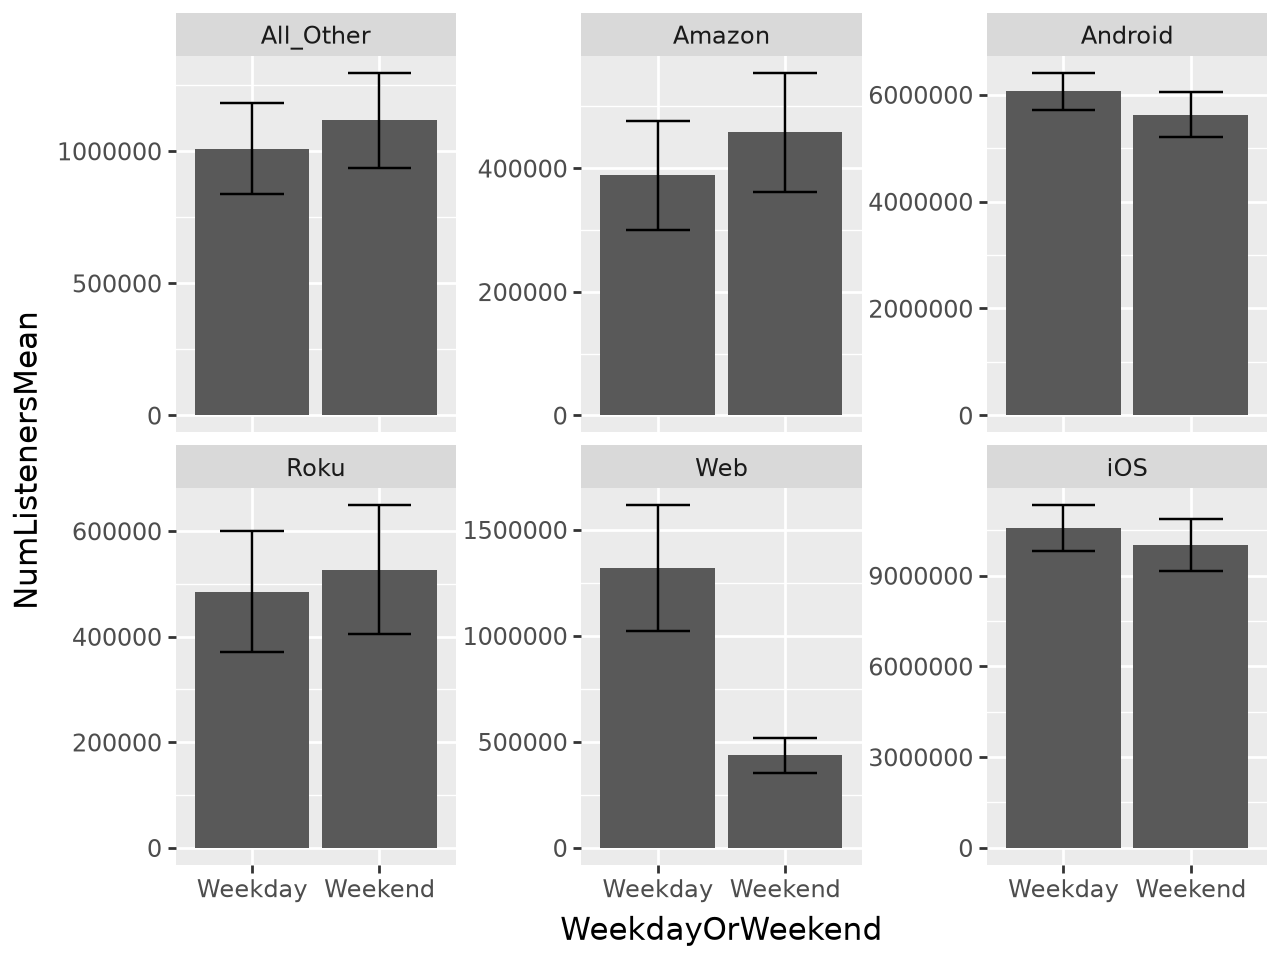

In [12]:
(
    df_du.group_by("DayOfWeekStr")
    .agg(col("NumListeners").mean())
)

df_du_by_day_of_week = (
    df_du.group_by("Platform", "DayOfWeek", "DayOfWeekStr")
    .agg(
        col("NumListeners").mean().alias("NumListenersMean"),
        col("NumListeners").std().alias("NumListenersStd"),
    )
)

df_du_by_weekend = (
    df_du.group_by("Platform", "WeekdayOrWeekend")
    .agg(
        col("NumListeners").mean().alias("NumListenersMean"),
        col("NumListeners").std().alias("NumListenersStd"),
    )
)

display(df_du_by_day_of_week, df_du_by_weekend)
(
    ggplot(data=df_du_by_day_of_week, mapping=aes(x="DayOfWeek", y="NumListenersMean"))
    + facet_wrap("Platform")
    + geom_col()
    + geom_errorbar(mapping=aes(ymin="NumListenersMean-NumListenersStd", ymax="NumListenersMean+NumListenersStd"))
)

(
    ggplot(data=df_du_by_weekend, mapping=aes(x="WeekdayOrWeekend", y="NumListenersMean"))
    + facet_wrap("Platform", scales="free_y")
    + geom_col()
    + geom_errorbar(mapping=aes(ymin="NumListenersMean-NumListenersStd", ymax="NumListenersMean+NumListenersStd"))
)

In [13]:
df_du_by_weekend

Platform,WeekdayOrWeekend,NumListenersMean,NumListenersStd
str,str,f64,f64
"""iOS""","""Weekday""",1.0569e7,746422.783667
"""All_Other""","""Weekend""",1.1162e6,178877.37308
"""Web""","""Weekday""",1.3178e6,296325.582939
"""iOS""","""Weekend""",1.0012e7,872550.703892
"""Amazon""","""Weekend""",458095.930265,96004.880619
…,…,…,…
"""Roku""","""Weekday""",485139.3334,114564.50029
"""All_Other""","""Weekday""",1.0085e6,171525.625102
"""Android""","""Weekend""",5.6240e6,417737.257465


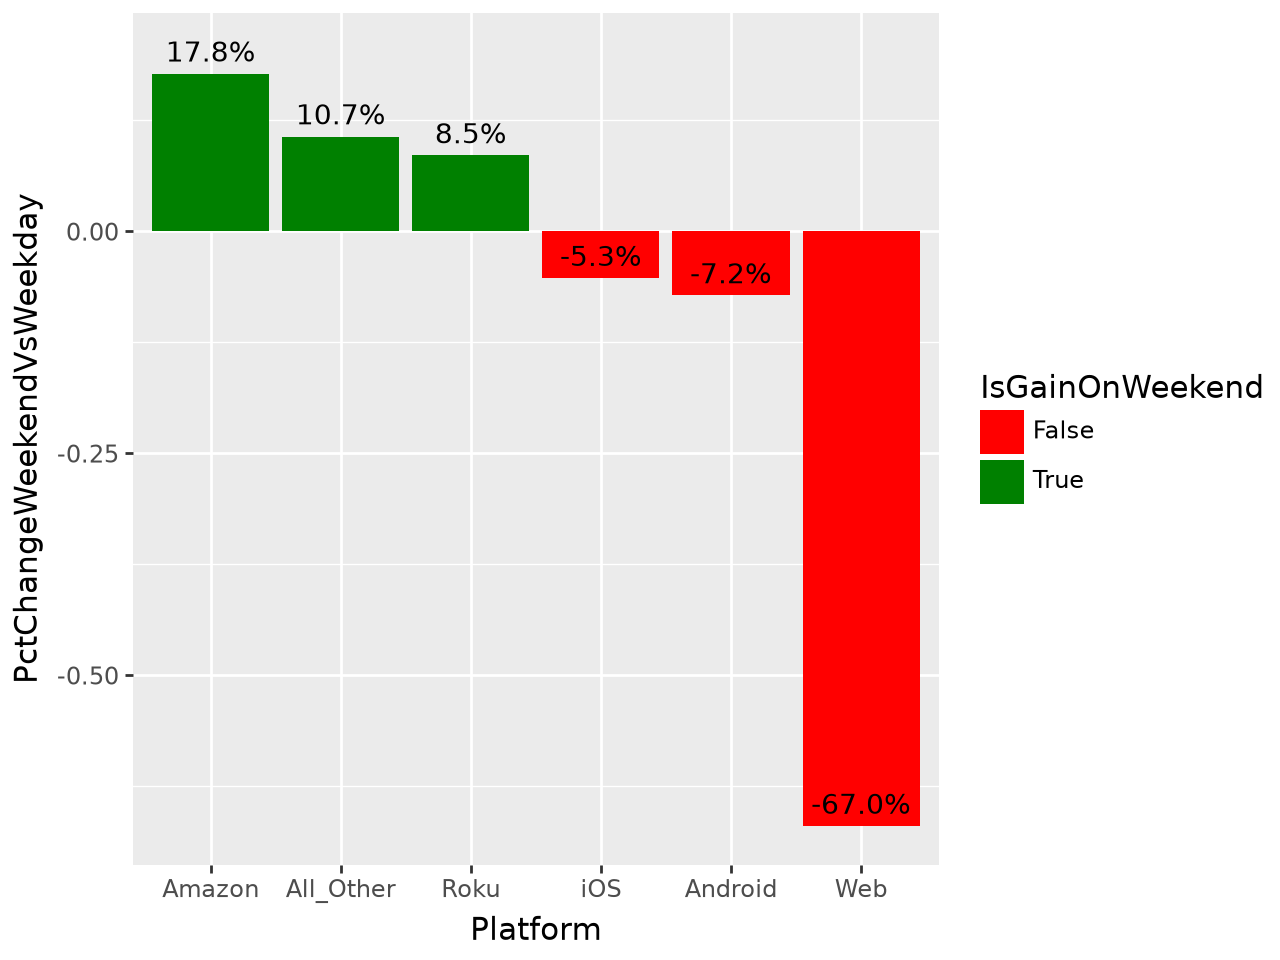

In [14]:
df_du_by_weekend_pct_change = (
    df_du_by_weekend.pivot(
        on="WeekdayOrWeekend",\
        index="Platform",
        values="NumListenersMean"
    )
    .select("Platform", "Weekday", "Weekend")
    .with_columns(
        (
            (col("Weekend") - col("Weekday")) 
            / col("Weekday")
        ).alias("PctChangeWeekendVsWeekday")
    )
    .with_columns(
        (col("PctChangeWeekendVsWeekday") > 0).alias("IsGainOnWeekend"),
        (
            (col("PctChangeWeekendVsWeekday") * 100)
                .round(1)
                .cast(pl.String) 
                + lit("%")
        ).alias("PctChangeLabel")
    )
)

order_platform_by_pct_change = (
    df_du_by_weekend_pct_change.select(["Platform", "PctChangeWeekendVsWeekday"])
    # .unique(subset=["Platform"])
    .sort("PctChangeWeekendVsWeekday", descending=True)
    .get_column("Platform")
    .to_list()
)


df_du_by_weekend_pct_change = df_du_by_weekend_pct_change.with_columns(
    col("Platform").cast(pl.Enum(categories=order_platform_by_pct_change))
)

df_du_by_weekend_pct_change

(
    ggplot(
        data=df_du_by_weekend_pct_change, 
        mapping=aes(x="Platform", y="PctChangeWeekendVsWeekday", fill="IsGainOnWeekend")
    )
    # + facet_wrap("Platform", scales="free_y")
    + geom_col()
    + geom_text(mapping=aes(label="PctChangeLabel"), nudge_y=.025, size=10)
    + scale_fill_manual({True: "green", False: "red"})
)

# platform_order_by_pct_change
# df_du_by_weekend_pct_change


In [15]:
fig = px.bar(
    df_du_by_weekend_pct_change,
    x="Platform",
    y="PctChangeWeekendVsWeekday",
    color="IsGainOnWeekend",
    text="PctChangeLabel",
    color_discrete_map={True: "green", False: "red"},
)

fig.update_traces(textposition="outside")

fig.show()

In [16]:

# Sort so bars stack/order correctly along the x-axis
df_mu = df_mu.sort(["Year", "Month"])
display(df_mu)
# Create stacked bar chart
fig = px.bar(
    df_mu,
    x="YearMonth",
    y="NumListeners",
    color="Platform",
    category_orders={"Platform": ["iOS", "Android",  "Web", "All_Other", "Roku", "Amazon",]}
)

fig.update_layout(
    barmode="stack", 
    bargap=0,
    xaxis_title="Year-Month", 
    yaxis_title="NumListeners",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray",
    gridwidth=1,
    griddash="dot",
    layer="above traces",
)

fig.show()

Year,Month,Platform,NumListeners,YearMonth,Date
i64,i64,str,f64,str,date
2018,1,"""Web""",8.1500e6,"""2018-01""",2018-01-01
2018,1,"""All_Other""",5.0546e6,"""2018-01""",2018-01-01
2018,1,"""Roku""",2.07789e6,"""2018-01""",2018-01-01
2018,1,"""Android""",1.8729e7,"""2018-01""",2018-01-01
2018,1,"""iOS""",2.7803e7,"""2018-01""",2018-01-01
…,…,…,…,…,…
2020,12,"""Android""",1.7230e7,"""2020-12""",2020-12-01
2020,12,"""Roku""",3399923.7,"""2020-12""",2020-12-01
2020,12,"""All_Other""",8201977.2,"""2020-12""",2020-12-01


In [17]:
fig.update_yaxes(
    range=[55_000_000, 70_000_000]
)

fig.show()

In [18]:
fig.write_html(
    "test_plot.html",
    include_plotlyjs="cdn",
    full_html=True
)